# Pneumonia Detection from Chest X-Rays

## Project Overview

In this project, I tried to build and train a deep learning model to detect pneumonia from chest X-ray images. It demonstrates the practical application of CNNs in medical imaging, including proper evaluation metrics, model interpretability, and ethical considerations.

**Clinical Context:**

Pneumonia is a serious lungs infection that affects millions globally. Early and accurate detection through chest X-ray is important for treatment. However, interpretation if the X-ray result requires expertise and can be time consuming. AI can help radiologists to achieve productivity through rapid preliminary assessments.

**Dataset:** Chest X-ray images (Padiatric patients, Guangzhou, China)

* **Normal:** Healthy lungs
* **Pneumonia:** Bacterial or viral pneumonia

**Project Goals:**

1. Build progressively sohpisticated CNN architectures.
2. Handle class imbalance in medical data.
3. Use proper medical evaluation metrics (prediction, recall, AUC).
4. Implement Grad-CAM for model interpretability.
5. Discuss ethical deployment considerations.

**Author:** Obadero Samuel

**Date:** 19/02/2026

**Github:** [github](https://github.com/Psalmmie)

## 1. Setup and Dependencies 

In [1]:
# Import PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

# Data handling and visualization
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from pathlib import Path
from tqdm import tqdm
import pandas as pd

# Metrics and evaluation
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

import seaborn as sns

# Experiment tracking 
from comet_ml import Experiment

# Grad-CAM for interpretability
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


### Check for GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

using device: cpu


# 2. Data Loading and Preprocessing

### 2.1 Download Dataset

**Dataset Source:** Chest X-ray Imaes (Pneumonia)

* **Kaggle:** https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
* **Images:** 5,863 X-ray images (JPEG)
* **Classes:** NORMAL / PNEUMONIA
* **Organization:** train/val/test folders with subfolders for each class

In [3]:
# Define data directories
DATA_DIR = Path('./data/chest_xray')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

# Model Parameters
IMG_SIZE = 224 # Standard for ImageNet pre-trained model
BATCH_SIZE = 16 # medical images can be large
NUM_CLASSES = 2 # Normal, Pneumonia
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

### 2.2 Exploratory Data Analysis

In [4]:
def count_images(directory):
    """Count images in each class."""
    counts = {}
    for class_name in CLASS_NAMES:
        class_dir = directory / class_name
        if class_dir.exists():
            counts[class_name] = len(list(class_dir.glob('*.jpeg')))
        else:
            counts[class_name] = 0
    return counts

# Count images in each split
train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("Dataset Distribution:")
print("="*43)
print(f"Training set:   Normal={train_counts['NORMAL']:<5} Pneumonia={train_counts['PNEUMONIA']}")
print(f"Validation Set: Normal={val_counts['NORMAL']:<5} Pneumonia={val_counts['PNEUMONIA']}")
print(f"Test Set:       Normal={test_counts['NORMAL']:<5} Pneumonia={test_counts['PNEUMONIA']}")
print("="*43)

# Calculate class imbalance ratio
total_normal = train_counts['NORMAL']
total_pneumonia = train_counts['PNEUMONIA']
imbalance_ratio = total_pneumonia / total_normal
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f} to 1 (Pneumonia to Normal)")
print(f"⚠️ Dataset is imbalanced!")

Dataset Distribution:
Training set:   Normal=1341  Pneumonia=3875
Validation Set: Normal=8     Pneumonia=8
Test Set:       Normal=234   Pneumonia=390

Class Imbalance Ratio: 2.89 to 1 (Pneumonia to Normal)
⚠️ Dataset is imbalanced!


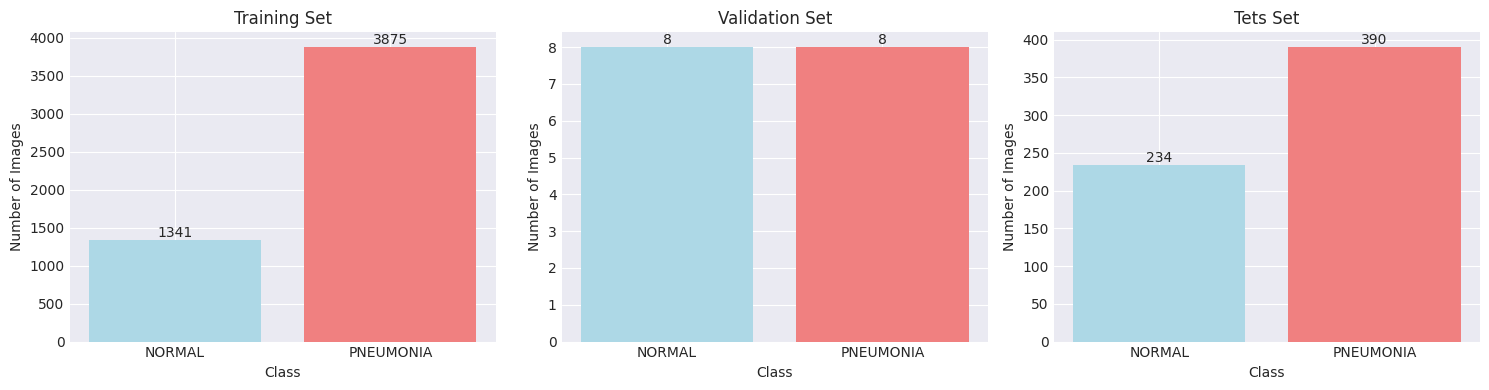

In [5]:
# Visualize the class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, counts) in zip(axes, [
    ('Training Set', train_counts),
    ('Validation Set', val_counts),
    ('Tets Set', test_counts)]):
    ax.bar(counts.keys(), counts.values(), color=['lightblue', 'lightcoral'])
    ax.set_title(title)
    ax.set_ylabel('Number of Images')
    ax.set_xlabel('Class')

    # Add value labels on bars
    for i, (key, value) in enumerate(counts.items()):
        ax.text(i, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()



### Visualizing X-Rays sample

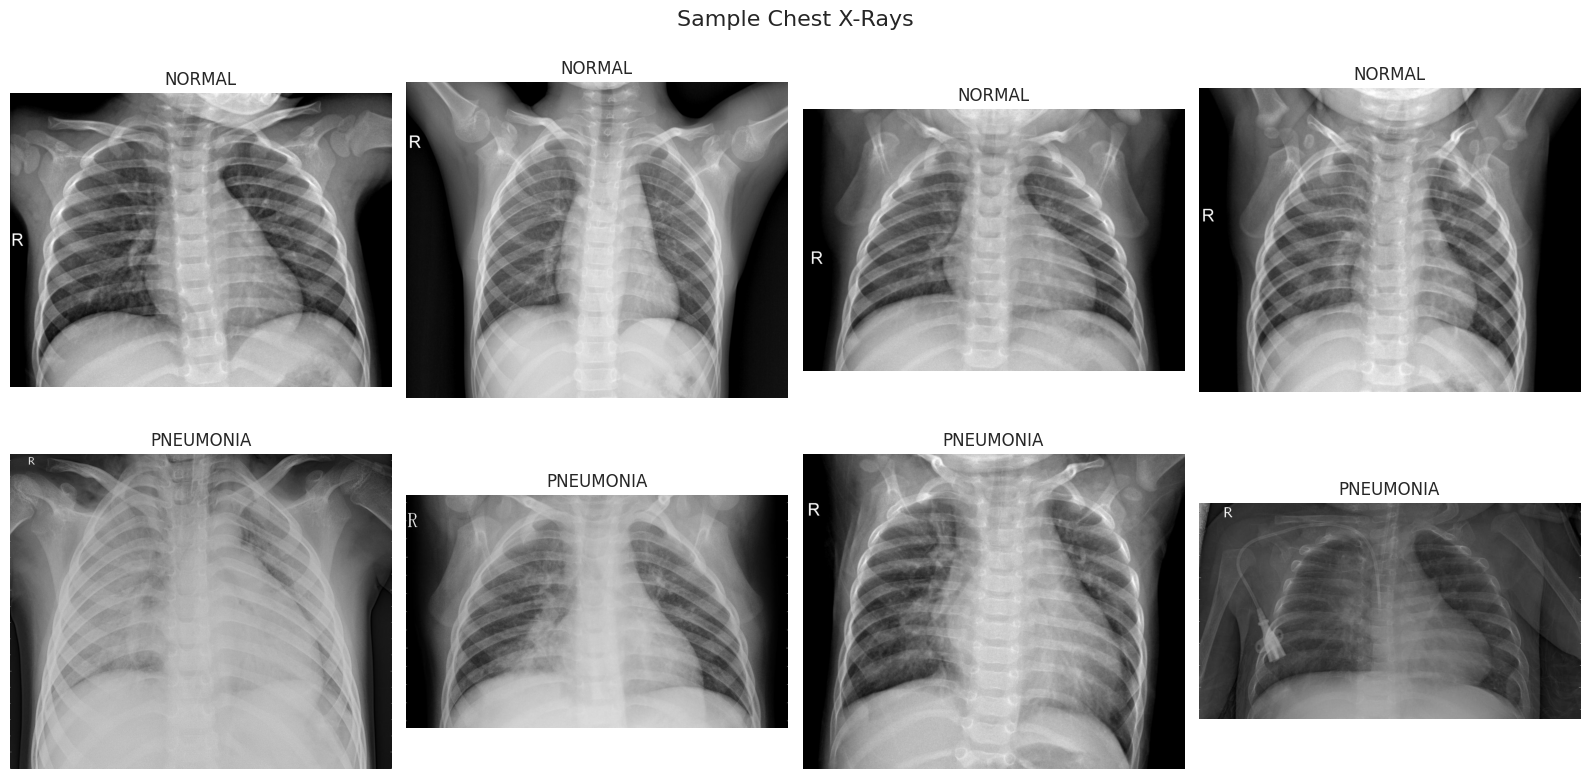

In [6]:
def visualize_sample(data_dir, num_sample):
    """Visualize X-Ray samples from both classes"""
    fig, axes = plt.subplots(2, num_sample//2, figsize=(16, 8))

    for idx, class_name in enumerate(CLASS_NAMES):
        class_dir = data_dir / class_name
        image_files = list(class_dir.glob('*.jpeg'))[:num_sample//2]

        for i, img_path in enumerate(image_files):
            img = Image.open(img_path).convert('L') # Grayscale
            axes[idx, i].imshow(img, cmap='gray')
            axes[idx, i].set_title(f"{class_name}")
            axes[idx, i].axis('off')

    plt.tight_layout()
    plt.suptitle('Sample Chest X-Rays', y =1.02, fontsize=16)
    plt.show()

visualize_sample(TRAIN_DIR, num_sample=8)

### 2.4 Custom Dataset Class

In [7]:
class ChestXrayDataset(Dataset):
    """Dataset for chest X-ray images."""

    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir: Directory with NORMAL and PNEUMONIA subfolders
            transform: Optional transform that can be applied to images
        """
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.class_names = CLASS_NAMES
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names) }

        # collate all image paths and labels
        self.images = []
        self.labels = []

        for class_name in self.class_names:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                continue

            for img_path in class_dir.glob('*.jpeg'):
                self.images.append(img_path)
                self.labels.append(self.class_to_idx[class_name])
        
        print(f"Loaded {len(self.images)} images from {root_dir.name}")
        print(f"    - Normal: {self.labels.count(0)}")
        print(f"    - Pneumonia: {self.labels.count(1)}")

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        # Load as grayscle and convert to RGB (3 channels) for pre-trained models
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label
    
    def get_class_weights(self):
        """Calculate class weights for handling imbalance"""
        class_counts = np.bincount(self.labels)
        weights = 1.0 / class_counts
        return torch.FloatTensor(weights)

### 2.5 Data Augumentation for Medical Images

The essence data augumentation is to avoid overfitting. This is because when model sees the same images repeatedly during training, there are tendencies of memorizing them rather than learning from them. Augumentation makes each epoch slighly different, forcing the model to learn robust features instead of memorizing.

In [8]:
# Training transforms with medical-appropriate augumentation
train_transform  = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10), # small rotation (patients can be slightly tilted)
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06)), # small translation
    transforms.RandomHorizontalFlip(p=0.3), # chest X-rays can be flipped
    transforms.ColorJitter(brightness=0.3, contrast=0.3), # exposure can be varied
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

#Validation/Test transforms (no augumentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### 2.6 Create Data Loaders with Class Balancing

Dataloader is an essential pipeline that feeds data to the model effeciently. Without it, we may have to manually handle how data gets to the model. It solves memory management, shuffling, and Parallelism. 

In [9]:
# Create datasets
train_dataset = ChestXrayDataset(TRAIN_DIR, transform=train_transform)
val_dataset = ChestXrayDataset(VAL_DIR, transform=val_transform)
test_dataset = ChestXrayDataset(TEST_DIR, transform=val_transform)

# calculate the class weight for balanced sampling
class_weights = train_dataset.get_class_weights()
sample_weights = [class_weights[label] for label in train_dataset.labels]
sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create data Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler = sampler, # Use weighted sampler for balancing
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("\n" + "="*51)
print("Data Loaders Created:")
print(f"    Training batches: {len(train_loader)}")
print(f"    Validation batches: {len(val_loader)}")
print(f"    Test batches: {len(test_loader)}")
print(f"    Batch size: {BATCH_SIZE}")
print("     ✓ Weighted sampling enabled for class balance")
print("="*51)

Loaded 5216 images from train
    - Normal: 1341
    - Pneumonia: 3875
Loaded 16 images from val
    - Normal: 8
    - Pneumonia: 8
Loaded 624 images from test
    - Normal: 234
    - Pneumonia: 390

Data Loaders Created:
    Training batches: 326
    Validation batches: 1
    Test batches: 39
    Batch size: 16
     ✓ Weighted sampling enabled for class balance


## 3. Model Architectures

We will implement three models:

1. **Custom CNN:** Built from scratch 
2. **ResNet50:** Transfer learning with frozen backbone
3. **DenseNet121:** State-of-the-art for mdeical imaging

### 3.1 Model 1: Custom CNN

In [10]:
class CustomCNN(nn.Module):
    """Custom CNN for pneumonia detection."""

    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()

        # Convolution blocks
        self.features = nn.Sequential(
            # Block 1 224x224x3 -> 112x112x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            # Block 2: 112x112x32 -> 56x56x64 
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            # Block 3: 56x56x64 -> 28x28x128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            # Block 4: 28x28x128 -> 14x14x256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
## Instantiate the model
custom_model = CustomCNN(num_classes=NUM_CLASSES).to(device)
print("Custom CNN Architecture:")
print(f"Total parameters: {sum(p.numel() for p in custom_model.parameters()):,}")

Custom CNN Architecture:
Total parameters: 1,306,786


### 3.2 Model 2: ResNet50 Transfer Learning

In [12]:
class ResNetTransfer(nn.Module):
    """ResNet50 with transfer learning."""

    def __init__(self, num_classes=2, freeze_backbone=True):
        super(ResNetTransfer, self).__init__()

        # Load pre-trained ResNet50
        self.resnet = models.resnet50(pretrained=True)

        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.resnet.parameters():
                param.requires_grad = False

        # Replace classifier
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

# Instantiate model
model_resnet = ResNetTransfer(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)
trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_resnet.parameters())
print("\nResNet50 Transfer Learning")
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")
print(f"Frozen: {(total-trainable)/total*100:.1f}%")


/home/obadero_oluwaseun/ENTER/envs/ML5_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/obadero_oluwaseun/ENTER/envs/ML5_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



ResNet50 Transfer Learning
Trainable parameters: 1,050,114
Total parameters: 24,558,146
Frozen: 95.7%


### 3.3 Model 3: DenseNet121 (Medical Imaging Standard)

The DenseNet 121 is a widely used mdeical imaging. It is preferred for medical imaging due to:

1. Its dense connections that preserve fine details.
2. Its efficeint feature propagation.
3. Its proven perforance on radiological images.

In [13]:
class DenseNetTransfer(nn.Module):
    """DenseNet121 - widely used in medical imaging."""

    def __init__(self, num_classes, freeze_backbone=True):
        super(DenseNetTransfer, self).__init__()

        # Load pre-trained DenseNet121
        self.densenet = models.densenet121(pretrained=True)

        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.densenet.parameters():
                param.requires_grad = False

        # Replace classifier
        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.densenet(x)
    
# Instantiate the model
model_densenet = DenseNetTransfer(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)
trainable = sum(p.numel() for p in model_densenet.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_densenet.parameters())
print("\nDenseNet121 Transfer Learning:")
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")
print(f"Frozen: {(total-trainable)/total*100:.1f}")

/home/obadero_oluwaseun/ENTER/envs/ML5_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



DenseNet121 Transfer Learning:
Trainable parameters: 525,826
Total parameters: 7,479,682
Frozen: 93.0


## Training with Medical Metrics

### 4.1 Training Functions with Comprehensive Metrics

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds) * 100

        return epoch_loss, epoch_acc
    
def validate(model, loader, criterion, device):
    """Validate with comprehensive medical metrics."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs= []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = F.softmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy()) # probability of pneumonia 
    
    epoch_loss = running_loss / len(loader.dataset)

    # Calculate medical metrics
    accuracy = accuracy_score(all_labels, all_preds) * 100
    precision = precision_score(all_labels, all_preds, zero_division=0) * 100
    recall = recall_score(all_labels, all_preds, zero_division=0) * 100 # sensitivity
    f1 = f1_score(all_labels, all_preds, zero_division=0) * 100

    # Calculate specificity (True Negative Rate)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    specificity = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0

    metrics = {
        'loss': epoch_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall, # sensitivity
        'specificity': specificity,
        'f1': f1,
        'probs': all_probs,
        'labels': all_labels
    }
    return metrics

def train_model(model, train_loader, val_loader, num_epochs=25, learning_rate=0.0001,
                class_weights=None, model_name="model"):
    
    """Complete training loop with comprehensive tracking"""

    # Loss function with class weights
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    else:
        criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr = learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=3
    )

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_precision': [], 'val_recall': [],
        'val_specificity': [], 'val_f1': []
    }

    best_val_f1 = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 70)

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        #validate
        val_metrics = validate(model, val_loader, criterion, device)

        # update learning rate
        scheduler.step(val_metrics['loss'])

        # store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_specificity'].append(val_metrics['specificity'])
        history['val_f1'].append(val_metrics['f1'])

        # Print metrics
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
        print(f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.2f}%")
        print(f"      - Precision: {val_metrics['precision']:.2f}%, "
              f"Recall: {val_metrics['recall']:.2f}%")
        print(f"      - Specificity: {val_metrics['specificity']:.2f}%, "
              f"F1: {val_metrics['f1']:.2f}%")
        
        # Save best model based on F1 score (balanced metric)
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f"✓ Best model saved (F1: {val_metrics['f1']:.2f}%)")
    
    return history


### 4.2 Train All Models

Now it is time to train all the three models above.

In [15]:
# Get class weights for loss function
class_weights_tensor = train_dataset.get_class_weights()
print(f"class_weights: {class_weights_tensor}")
print("\nStarting Training...\n")

class_weights: tensor([0.0007, 0.0003])

Starting Training...



In [16]:
# Train Model 1: Custom CNN
print("="*70)
print("TRAINING CUSTOM CNN")
print("="*70)
history_custom = train_model(
    custom_model,
    train_loader,
    val_loader,
    num_epochs=25,
    learning_rate=0.001,
    class_weights=class_weights_tensor,
    model_name="custom_cnn"
)

TRAINING CUSTOM CNN

Epoch 1/25
----------------------------------------------------------------------


Train - Loss: 0.0021, Acc: 43.75%
Val   - Loss: 0.6809, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 2/25
----------------------------------------------------------------------


Train - Loss: 0.0021, Acc: 37.50%
Val   - Loss: 0.6851, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 3/25
----------------------------------------------------------------------


Train - Loss: 0.0019, Acc: 37.50%
Val   - Loss: 0.6923, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 4/25
----------------------------------------------------------------------


Train - Loss: 0.0017, Acc: 50.00%
Val   - Loss: 0.7034, Acc: 50.00%
      - Precision: 50.00%, Recall: 100.00%
      - Specificity: 0.00%, F1: 66.67%
✓ Best model saved (F1: 66.67%)

Epoch 5/25
----------------------------------------------------------------------


...

Train - Loss: 0.0020, Acc: 50.00%
Val   - Loss: 1.0829, Acc: 50.00%
      - Precision: 50.00%, Recall: 100.00%
      - Specificity: 0.00%, F1: 66.67%

Epoch 22/25
----------------------------------------------------------------------


Train - Loss: 0.0012, Acc: 68.75%
Val   - Loss: 1.0849, Acc: 50.00%
      - Precision: 50.00%, Recall: 100.00%
      - Specificity: 0.00%, F1: 66.67%

Epoch 23/25
----------------------------------------------------------------------


Train - Loss: 0.0015, Acc: 50.00%
Val   - Loss: 1.0832, Acc: 50.00%
      - Precision: 50.00%, Recall: 100.00%
      - Specificity: 0.00%, F1: 66.67%

Epoch 24/25
----------------------------------------------------------------------


Train - Loss: 0.0012, Acc: 68.75%
Val   - Loss: 1.0830, Acc: 50.00%
      - Precision: 50.00%, Recall: 100.00%
      - Specificity: 0.00%, F1: 66.67%

Epoch 25/25
----------------------------------------------------------------------


Train - Loss: 0.0018, Acc: 50.00%
Val   - Loss: 1.0853, Acc: 50.00%
      - Precision: 50.00%, Recall: 100.00%
      - Specificity: 0.00%, F1: 66.67%


In [17]:
# Train Model 2: ResNet50
print("="*70)
print("TRAINING RESNET50")
print("="*70)
history_resnet = train_model(
    model_resnet,
    train_loader,
    val_loader,
    num_epochs=15,
    learning_rate=0.0001,
    class_weights = class_weights_tensor,
    model_name="resnet50"
)

TRAINING RESNET50

Epoch 1/15
----------------------------------------------------------------------


Train - Loss: 0.0022, Acc: 18.75%
Val   - Loss: 0.6711, Acc: 37.50%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 75.00%, F1: 0.00%

Epoch 2/15
----------------------------------------------------------------------


Train - Loss: 0.0020, Acc: 56.25%
Val   - Loss: 0.6177, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 3/15
----------------------------------------------------------------------


Train - Loss: 0.0023, Acc: 18.75%
Val   - Loss: 0.6118, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 4/15
----------------------------------------------------------------------


Train - Loss: 0.0018, Acc: 50.00%
Val   - Loss: 0.5898, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 5/15
----------------------------------------------------------------------


...

Train - Loss: 0.0011, Acc: 68.75%
Val   - Loss: 0.5824, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 12/15
----------------------------------------------------------------------


Train - Loss: 0.0015, Acc: 56.25%
Val   - Loss: 0.5796, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 13/15
----------------------------------------------------------------------


Train - Loss: 0.0015, Acc: 50.00%
Val   - Loss: 0.5754, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 14/15
----------------------------------------------------------------------


Train - Loss: 0.0014, Acc: 56.25%
Val   - Loss: 0.5724, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 15/15
----------------------------------------------------------------------


Train - Loss: 0.0010, Acc: 75.00%
Val   - Loss: 0.5709, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%


In [18]:
# Train Model 3: DenseNet121
print("\n" + "="*70)
print("TRAINING DENSENET121")
print("="*70)
history_densenet = train_model(
    model_densenet,
    train_loader,
    val_loader,
    num_epochs=15,
    learning_rate=0.0001,
    class_weights=class_weights_tensor,
    model_name="densenet121"
)


TRAINING DENSENET121

Epoch 1/15
----------------------------------------------------------------------


Train - Loss: 0.0020, Acc: 37.50%
Val   - Loss: 0.7109, Acc: 31.25%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 62.50%, F1: 0.00%

Epoch 2/15
----------------------------------------------------------------------


Train - Loss: 0.0017, Acc: 75.00%
Val   - Loss: 0.6655, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 3/15
----------------------------------------------------------------------


Train - Loss: 0.0018, Acc: 62.50%
Val   - Loss: 0.6364, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 4/15
----------------------------------------------------------------------


Train - Loss: 0.0021, Acc: 37.50%
Val   - Loss: 0.6213, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 5/15
----------------------------------------------------------------------


...

Train - Loss: 0.0022, Acc: 37.50%
Val   - Loss: 0.6022, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 12/15
----------------------------------------------------------------------


Train - Loss: 0.0021, Acc: 43.75%
Val   - Loss: 0.5975, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 13/15
----------------------------------------------------------------------


Train - Loss: 0.0019, Acc: 43.75%
Val   - Loss: 0.5930, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 14/15
----------------------------------------------------------------------


Train - Loss: 0.0013, Acc: 62.50%
Val   - Loss: 0.5879, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%

Epoch 15/15
----------------------------------------------------------------------


Train - Loss: 0.0015, Acc: 50.00%
Val   - Loss: 0.5852, Acc: 50.00%
      - Precision: 0.00%, Recall: 0.00%
      - Specificity: 100.00%, F1: 0.00%


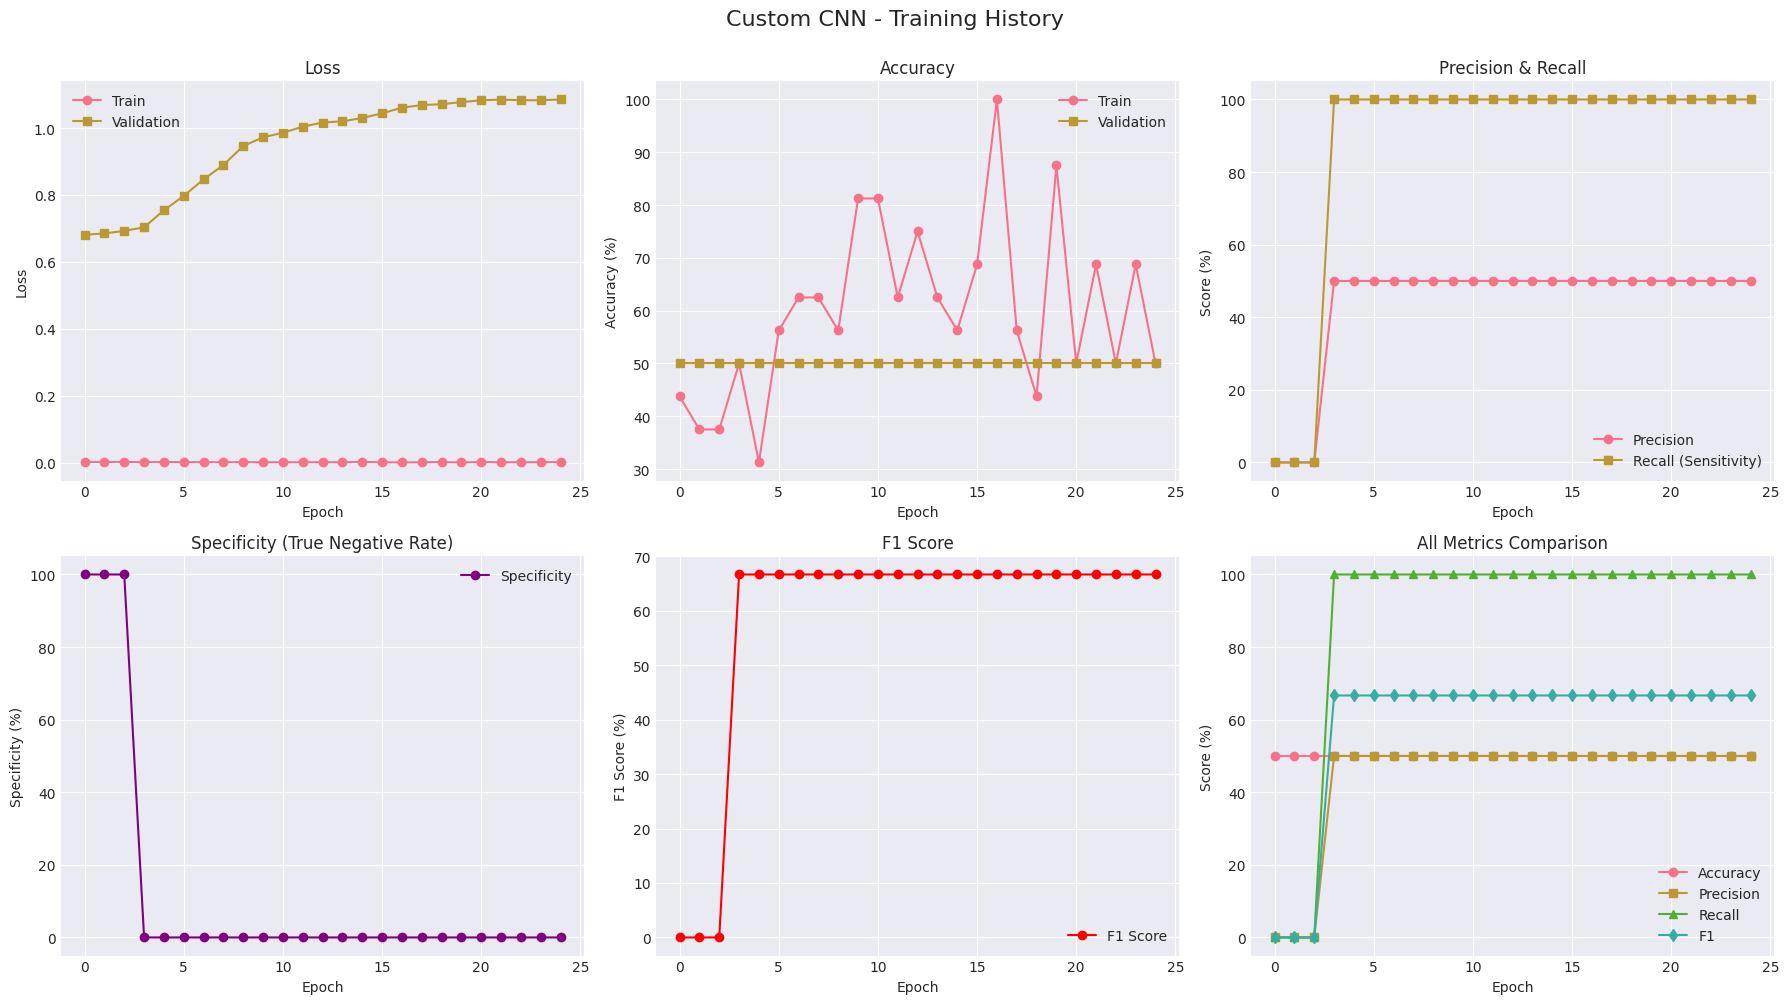

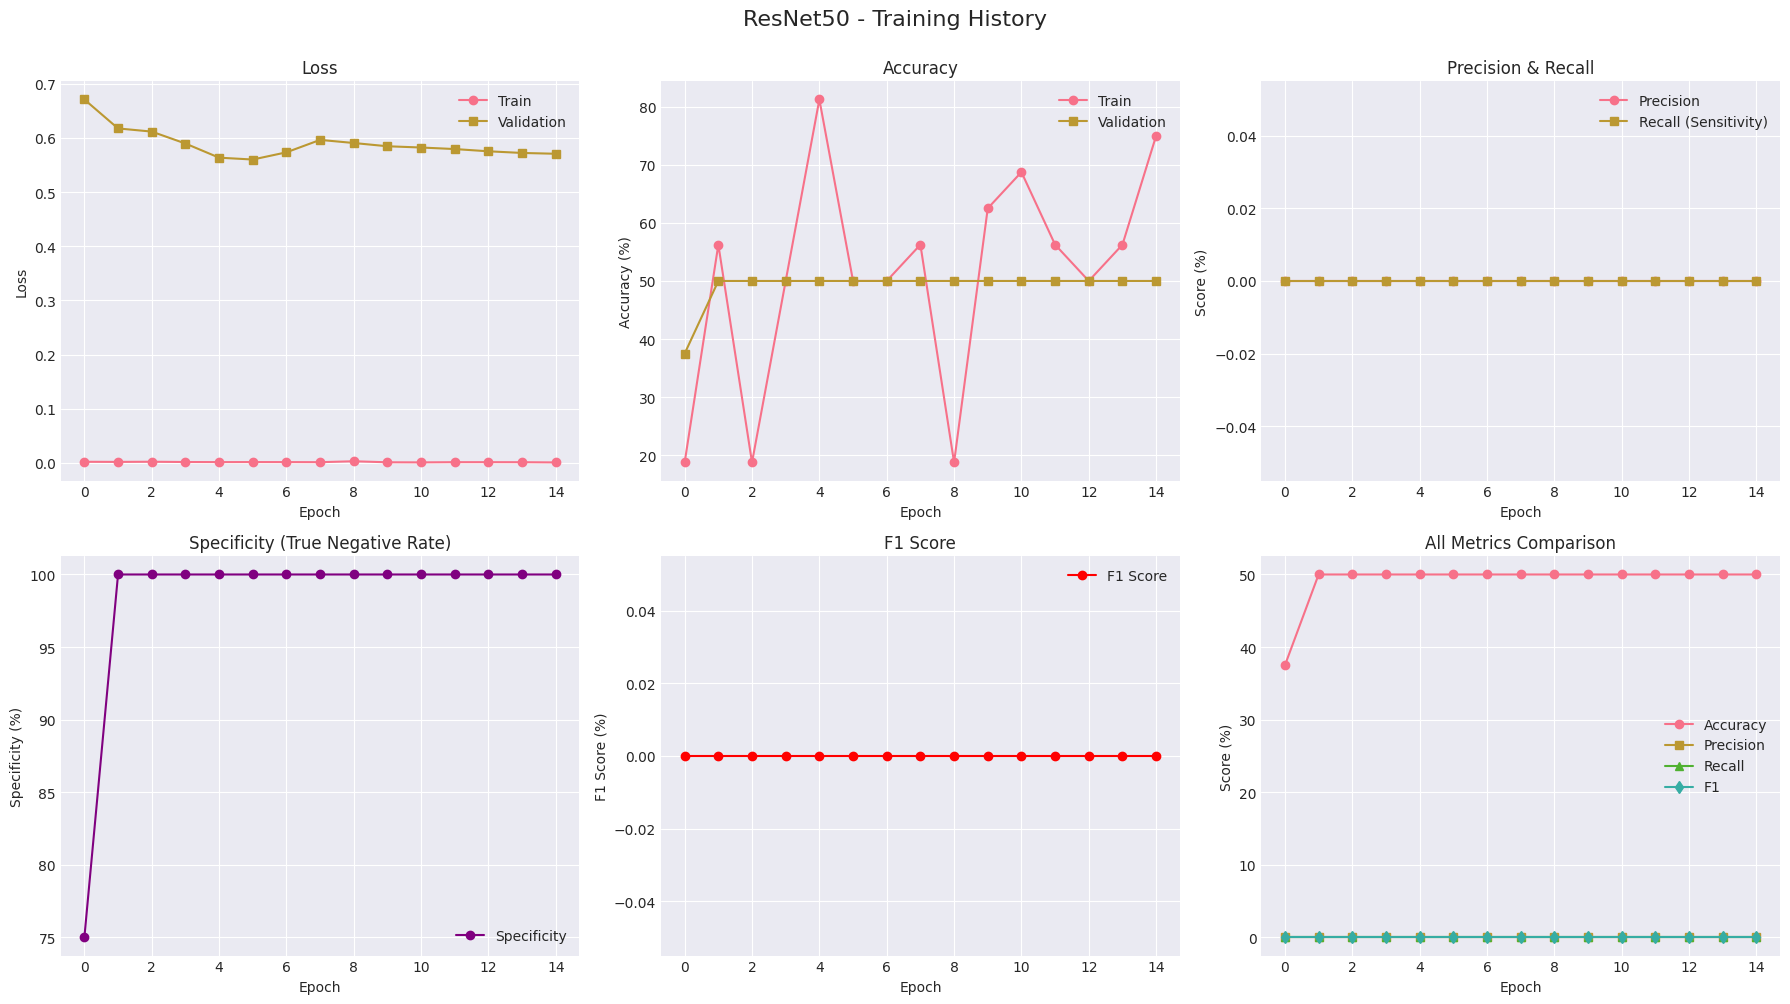

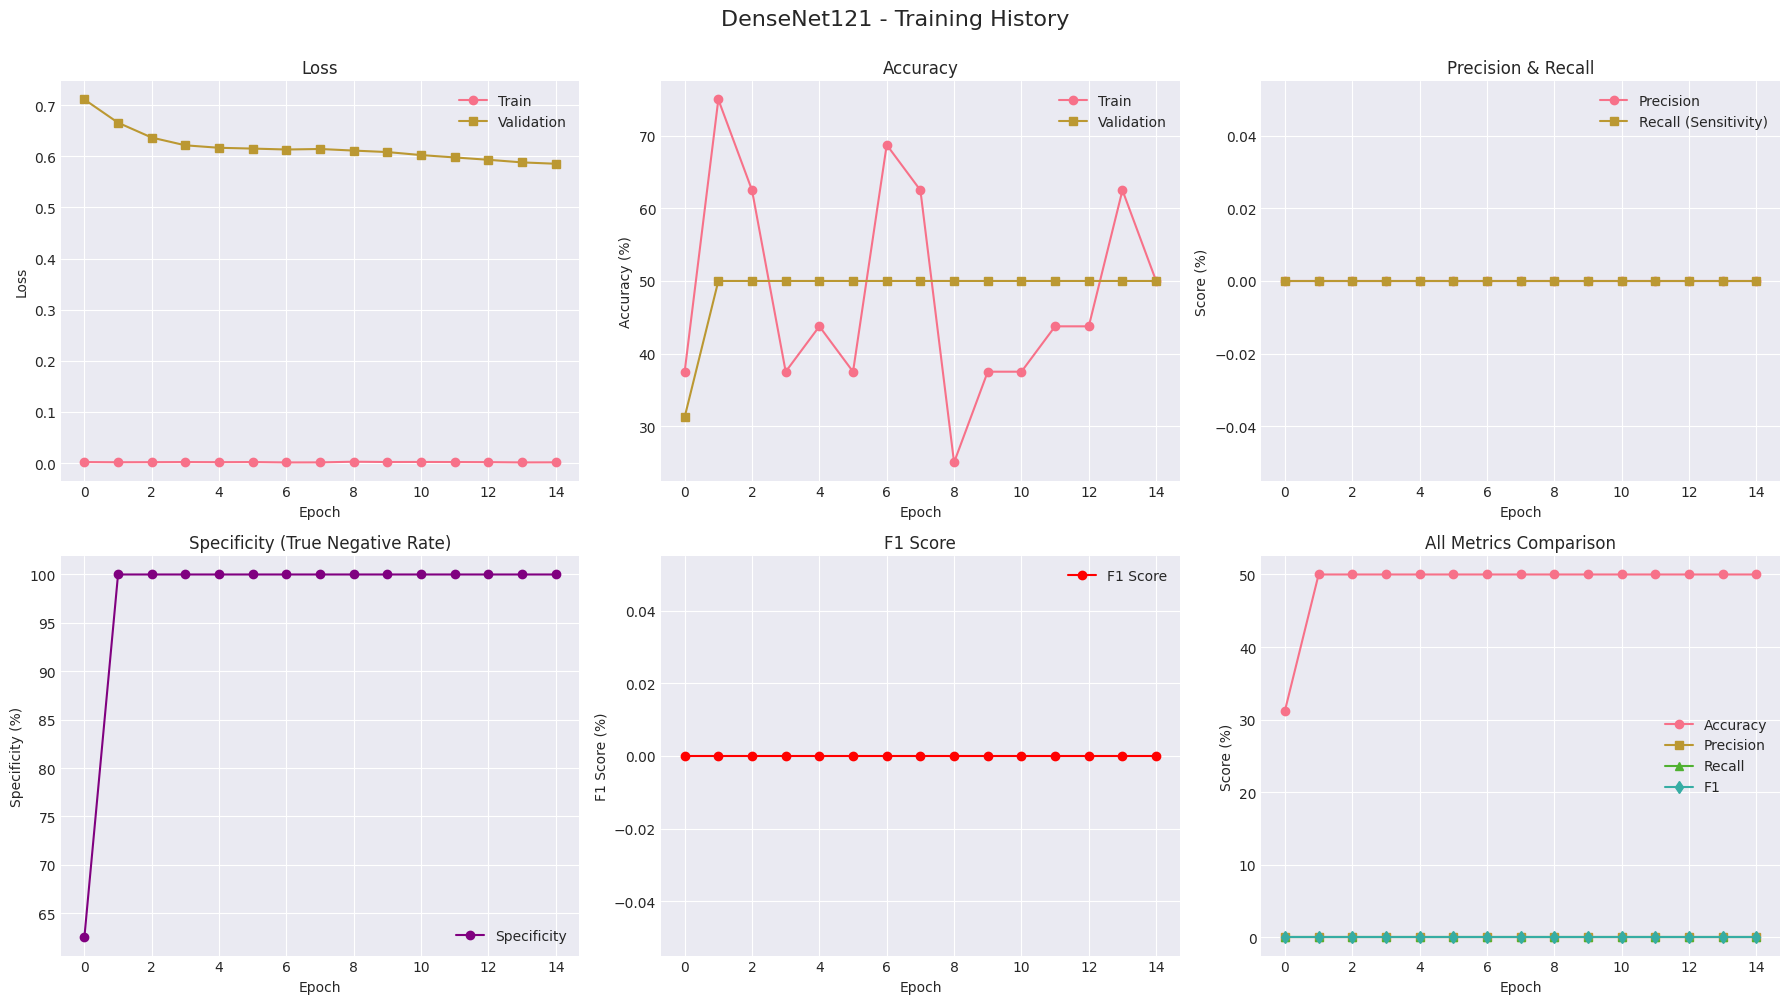

In [19]:
def plot_training_history(history, title):
    """Plot comprehensive training metrics."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train', marker='o')
    axes[0, 0].plot(history['val_loss'], label='Validation', marker='s')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train', marker='o')
    axes[0, 1].plot(history['val_acc'], label='Validation', marker='s')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Precision & Recall
    axes[0, 2].plot(history['val_precision'], label='Precision', marker='o')
    axes[0, 2].plot(history['val_recall'], label='Recall (Sensitivity)', marker='s')
    axes[0, 2].set_title('Precision & Recall')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Score (%)')
    axes[0, 2].legend()
    axes[0, 2].grid(True)
    
    # Specificity
    axes[1, 0].plot(history['val_specificity'], label='Specificity', marker='o', color='purple')
    axes[1, 0].set_title('Specificity (True Negative Rate)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Specificity (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # F1 Score
    axes[1, 1].plot(history['val_f1'], label='F1 Score', marker='o', color='red')
    axes[1, 1].set_title('F1 Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1 Score (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # All validation metrics together
    axes[1, 2].plot(history['val_acc'], label='Accuracy', marker='o')
    axes[1, 2].plot(history['val_precision'], label='Precision', marker='s')
    axes[1, 2].plot(history['val_recall'], label='Recall', marker='^')
    axes[1, 2].plot(history['val_f1'], label='F1', marker='d')
    axes[1, 2].set_title('All Metrics Comparison')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Score (%)')
    axes[1, 2].legend()
    axes[1, 2].grid(True)
    
    plt.suptitle(title, fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()

# Plot all models
plot_training_history(history_custom, "Custom CNN - Training History")
plot_training_history(history_resnet, "ResNet50 - Training History")
plot_training_history(history_densenet, "DenseNet121 - Training History")